<a href="https://colab.research.google.com/github/thisishasan/cbir_system/blob/main/28_comparing_retrieval_subclass_scenario.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd '/content/drive/My Drive/01_information_retrieval'

/content/drive/My Drive/01_information_retrieval


In [3]:
def euclidean(a, b):
	# compute and return the euclidean distance between two vectors
	return np.linalg.norm(a - b)

def perform_search(query_features, indexed_train, max_results=5):
	retrieved = []
	for idx in range(0, len(indexed_train["features"])):
		distance = euclidean(query_features, indexed_train["features"][idx])
		retrieved.append((distance, idx))
	retrieved = sorted(retrieved)[:max_results]
	return retrieved

In [4]:
import copy
import numpy as np
import os
import matplotlib.pyplot as plt
import json
import cv2
import sklearn.metrics as metric
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Conv2DTranspose
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Reshape
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
import pandas as pd

In [5]:
class ConvAutoEncoder:
    @staticmethod
    def build(width, height, depth, filters=(128,), latent_dim=48):
        input_shape = (height, width, depth)
        channel_dim = -1
        inputs = Input(shape=input_shape)
        x = inputs
        # Encoder layer
        for f in filters:
            x = Conv2D(f, (3, 3), strides=2, padding='same')(x)
            x = LeakyReLU(negative_slope=0.2)(x)
            x = BatchNormalization(axis=channel_dim, name='enc_filter_'+str(f))(x)

        volume_size = K.int_shape(x)
        x = Flatten()(x)
        # Latent layer
        latent = Dense(latent_dim, name="encoded")(x)

        # Decoder layer
        x = Dense(int(np.prod(volume_size[1:])))(latent)
        x = Reshape((volume_size[1], volume_size[2], volume_size[3]))(x)

        # Reverse on decoder
        for f in filters[::-1]:
            x = Conv2DTranspose(f, (3, 3), strides=2, padding='same')(x)
            x = LeakyReLU(negative_slope=0.2)(x)
            x = BatchNormalization(axis=channel_dim, name='dec_filter_'+str(f))(x)

        x = Conv2DTranspose(depth, (3, 3), padding="same")(x)
        outputs = Activation("sigmoid", name="decoded")(x)

        auto_encoder = Model(inputs, outputs, name="auto_encoder")
        return auto_encoder

In [6]:
base_dataset = "subclass_scenario"
magnification = "400X"
class_dir = ['tubular_adenoma', 'phyllodes_tumor', 'papillary_carcinoma',
             'mucinous_carcinoma', 'lobular_carcinoma', 'fibroadenoma',
             'ductal_carcinoma', 'adenosis']
IMAGE_SIZE = (256, 256)

In [7]:
print("[INFO] indexing file images BreaKHis dataset...")
# indexing file images
dataset = []
for class_item in class_dir:
    cur_dir = os.path.join(base_dataset, 'test', magnification, class_item)
    for file in os.listdir(cur_dir):
        dataset.append(os.path.join(cur_dir, file))

[INFO] indexing file images BreaKHis dataset...


In [8]:
dataset_train = []
for class_item in class_dir:
    cur_dir = os.path.join(base_dataset, 'train', magnification, class_item)
    for file in os.listdir(cur_dir):
        dataset_train.append(os.path.join(cur_dir, file))


In [9]:
images_train = []
for image_path in dataset_train:
    if ".png" in image_path:
        image = cv2.imread(image_path)
        image = cv2.resize(image, IMAGE_SIZE)
        images_train.append(image)

In [10]:
print("[INFO] load images BreaKHis dataset...")
#  load images
images = []
for image_path in dataset:
    if ".png" in image_path:
        image = cv2.imread(image_path)
        image = cv2.resize(image, IMAGE_SIZE)
        images.append(image)

[INFO] load images BreaKHis dataset...


In [11]:
# normalization
print("[INFO] normalization...")
test_x = np.array(images).astype("float32") / 255.0

[INFO] normalization...


In [12]:
# 400X
auto_encoder_400= ConvAutoEncoder.build(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
auto_encoder_400.load_weights("training_1_400_subclass/cp.ckpt.weights.h5")
with open('training_1_indexed_400_subclass.json') as f:
  training_indexed_400 = json.load(f)
encoder_400 = Model(inputs=auto_encoder_400.input,
	outputs=auto_encoder_400.get_layer("encoded").output)

In [13]:
import tensorflow as tf
import pathlib
def save_model(model, filename):
  converter = tf.lite.TFLiteConverter.from_keras_model(model)
  converter.optimizations = [tf.lite.Optimize.DEFAULT]
  tflite_model = converter.convert()
  tflite_models_dir = pathlib.Path("/content/drive/My Drive/01_information_retrieval/tflite_model/")
  tflite_models_dir.mkdir(exist_ok=True, parents=True)
  tflite_model_file = tflite_models_dir/("{}.tflite".format(filename))
  tflite_model_file.write_bytes(tflite_model)

In [14]:
# 200X
auto_encoder_200= ConvAutoEncoder.build(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
auto_encoder_200.load_weights("training_1_200_subclass/cp.ckpt.weights.h5")
with open('training_1_indexed_200_subclass.json') as f:
  training_indexed_200 = json.load(f)
encoder_200 = Model(inputs=auto_encoder_200.input,
	outputs=auto_encoder_200.get_layer("encoded").output)

In [15]:
# 100X
auto_encoder_100 = ConvAutoEncoder.build(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
auto_encoder_100.load_weights("training_1_100_subclass/cp.ckpt.weights.h5")
with open('training_1_indexed_100_subclass.json') as f:
  training_indexed_100 = json.load(f)
encoder_100 = Model(inputs=auto_encoder_100.input,
	outputs=auto_encoder_100.get_layer("encoded").output)

In [16]:
# 40X
auto_encoder_40 = ConvAutoEncoder.build(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
auto_encoder_40.load_weights("training_1_40_subclass/cp.ckpt.weights.h5")
with open('training_1_indexed_40_subclass.json') as f:
  training_indexed_40 = json.load(f)
encoder_40 = Model(inputs=auto_encoder_40.input,
	outputs=auto_encoder_40.get_layer("encoded").output)

In [17]:
save_model(encoder_400, 'subclass_encoder_400')
save_model(encoder_200, 'subclass_encoder_200')
save_model(encoder_100, 'subclass_encoder_100')
save_model(encoder_40, 'subclass_encoder_40')

Saved artifact at '/tmp/tmpibpeehjt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 48), dtype=tf.float32, name=None)
Captures:
  132020567139984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132020567140176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132018211112720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132018211112912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132018211112336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132018211113488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132020567138832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132020567139408: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved artifact at '/tmp/tmp9s7bgxc2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 2

In [18]:
test_sample = test_x[10, :, : ,:].reshape(1, 256, 256, 3)

In [19]:
features_retrieved_400 = encoder_400.predict(test_sample)
features_retrieved_200 = encoder_200.predict(test_sample)
features_retrieved_100 = encoder_100.predict(test_sample)
features_retrieved_40 = encoder_40.predict(test_sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


In [20]:
query_indexes = list(range(0, test_x.shape[0]))
label_builder = list(np.unique(training_indexed_400["labels"]))
class_builder = {label_unique:[] for label_unique in label_builder}

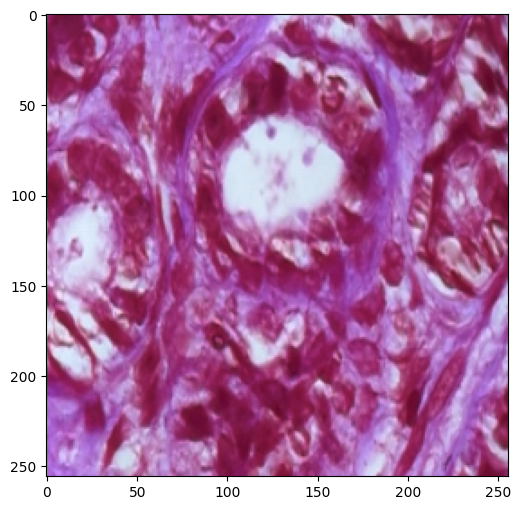

In [21]:
plt.figure(figsize=(6,6))
plt.imshow(test_x[10])
plt.show()

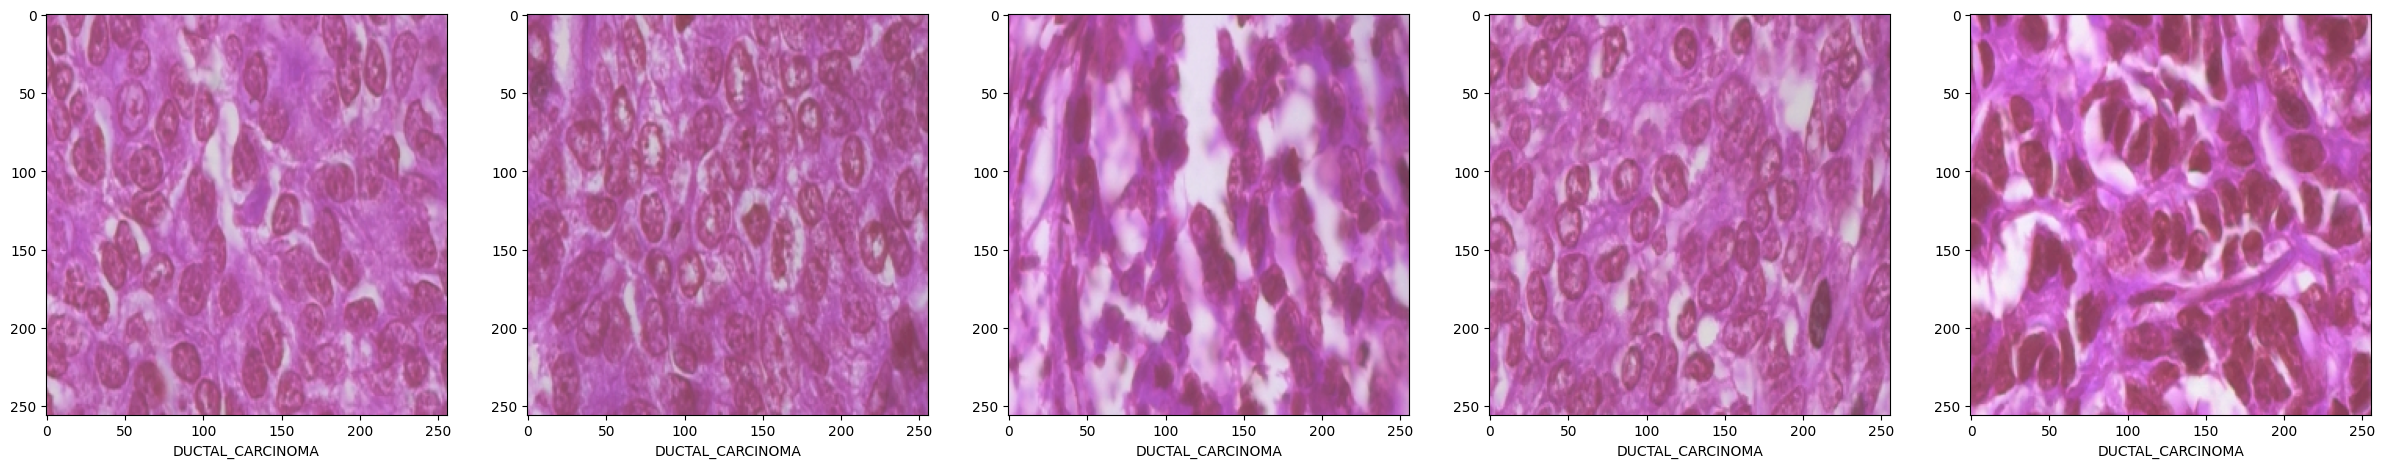

In [22]:
queryFeatures = features_retrieved_400[0]
results = perform_search(queryFeatures, training_indexed_400, max_results=5)
labels_ret = [training_indexed_400["labels"][r[1]] for r in results]

i = 0
f, axarr = plt.subplots(1, 5)
f.set_figheight(20)
f.set_figwidth(30)
for l in labels_ret:
  axarr[i].imshow(images_train[results[i][1]])
  axarr[i].set_xlabel(l.upper())
  i += 1
plt.show()

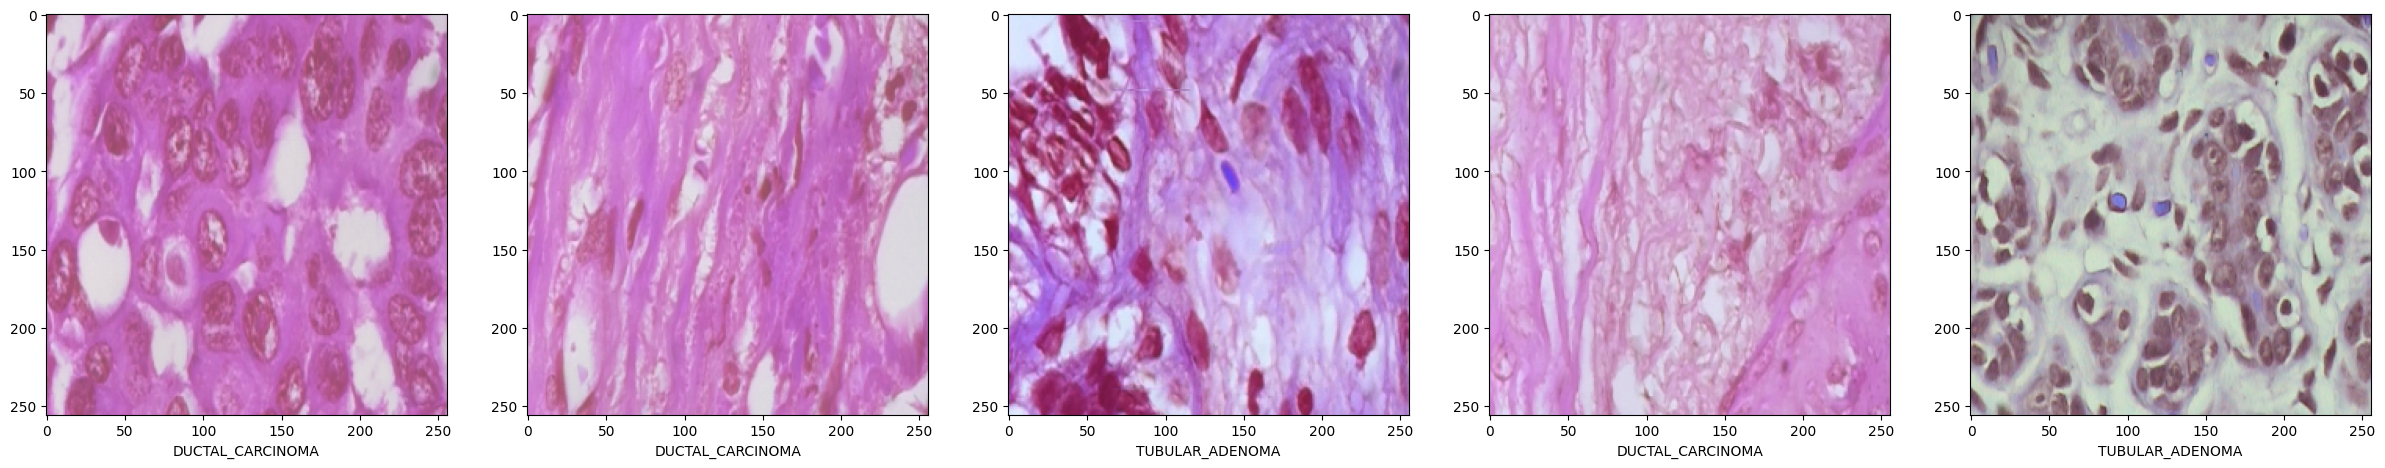

In [23]:
queryFeatures = features_retrieved_200[0]
results = perform_search(queryFeatures, training_indexed_200, max_results=5)
labels_ret = [training_indexed_200["labels"][r[1]] for r in results]

i = 0
f, axarr = plt.subplots(1, 5)
f.set_figheight(20)
f.set_figwidth(30)
for l in labels_ret:
  axarr[i].imshow(images_train[results[i][1]])
  axarr[i].set_xlabel(l.upper())
  i += 1
plt.show()

0
3


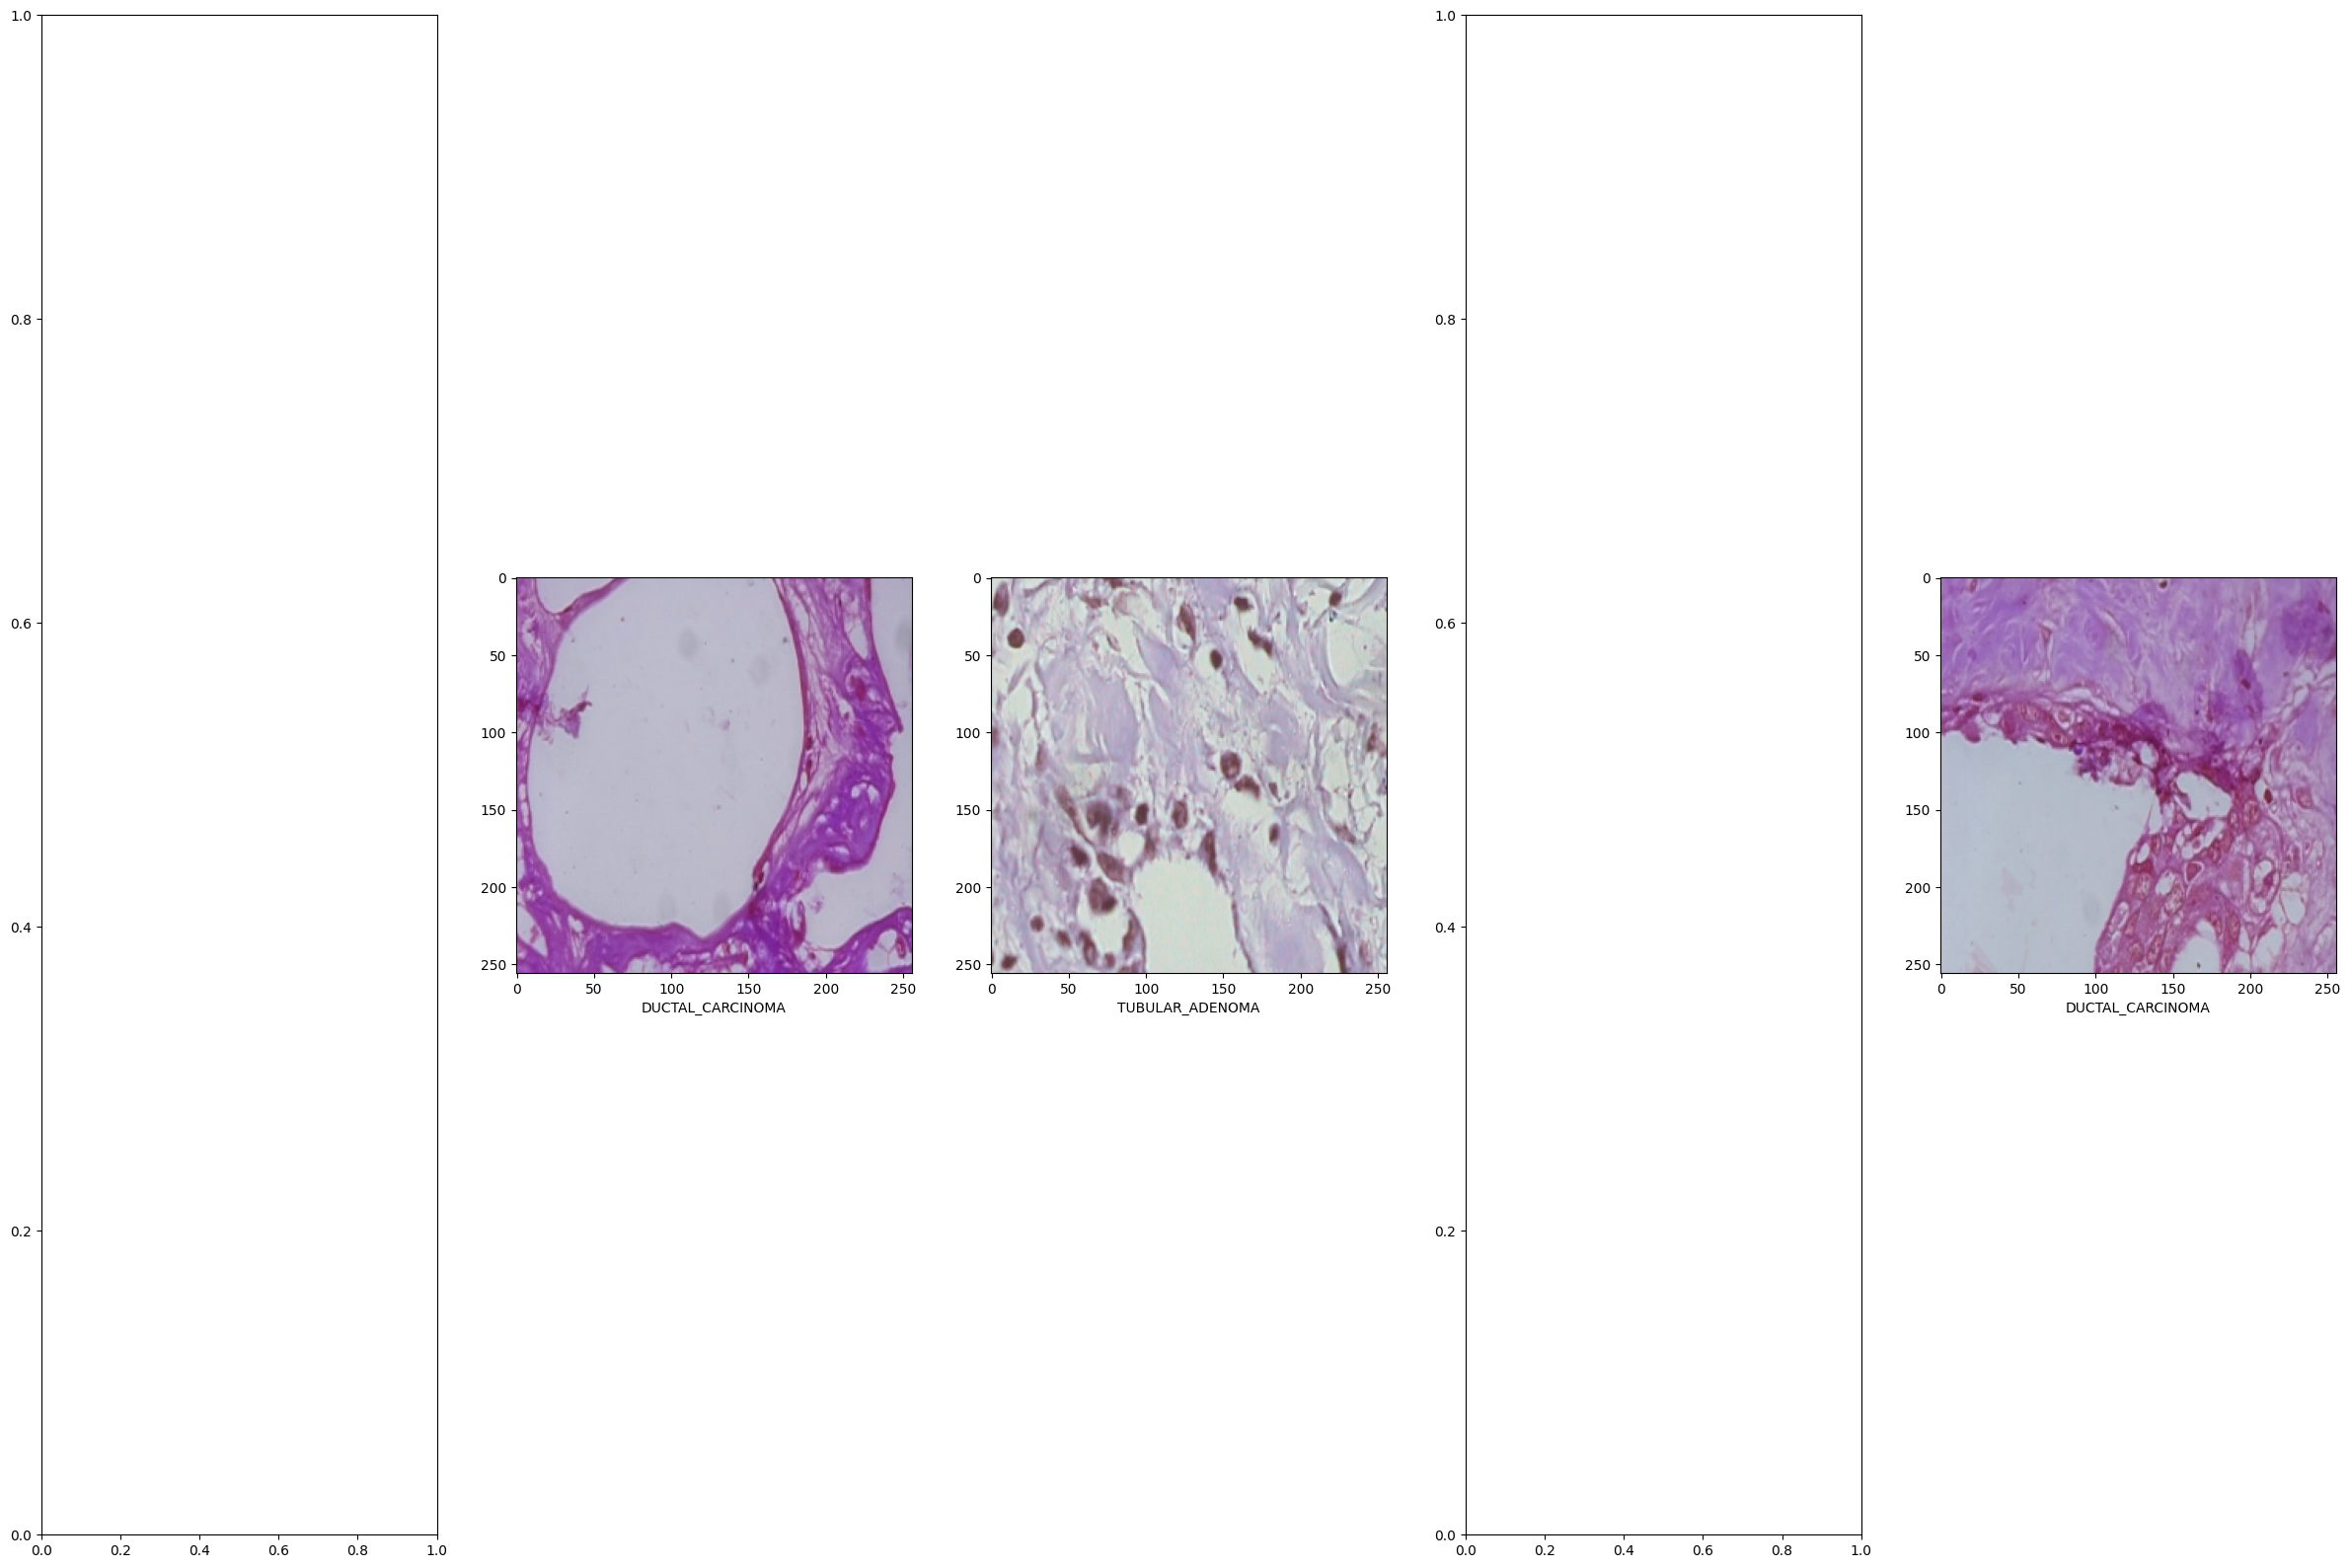

In [52]:
queryFeatures = features_retrieved_100[0]
results = perform_search(queryFeatures, training_indexed_100, max_results=5)
labels_ret = [training_indexed_100["labels"][r[1]] for r in results]

i = 0
f, axarr = plt.subplots(1, 5)
f.set_figheight(20)
f.set_figwidth(30)
for l in labels_ret:
  try:
    axarr[i].imshow(images_train[results[i][1]])
    axarr[i].set_xlabel(l.upper())
  except:
    print(i)
  i += 1
plt.show()

0
1
4


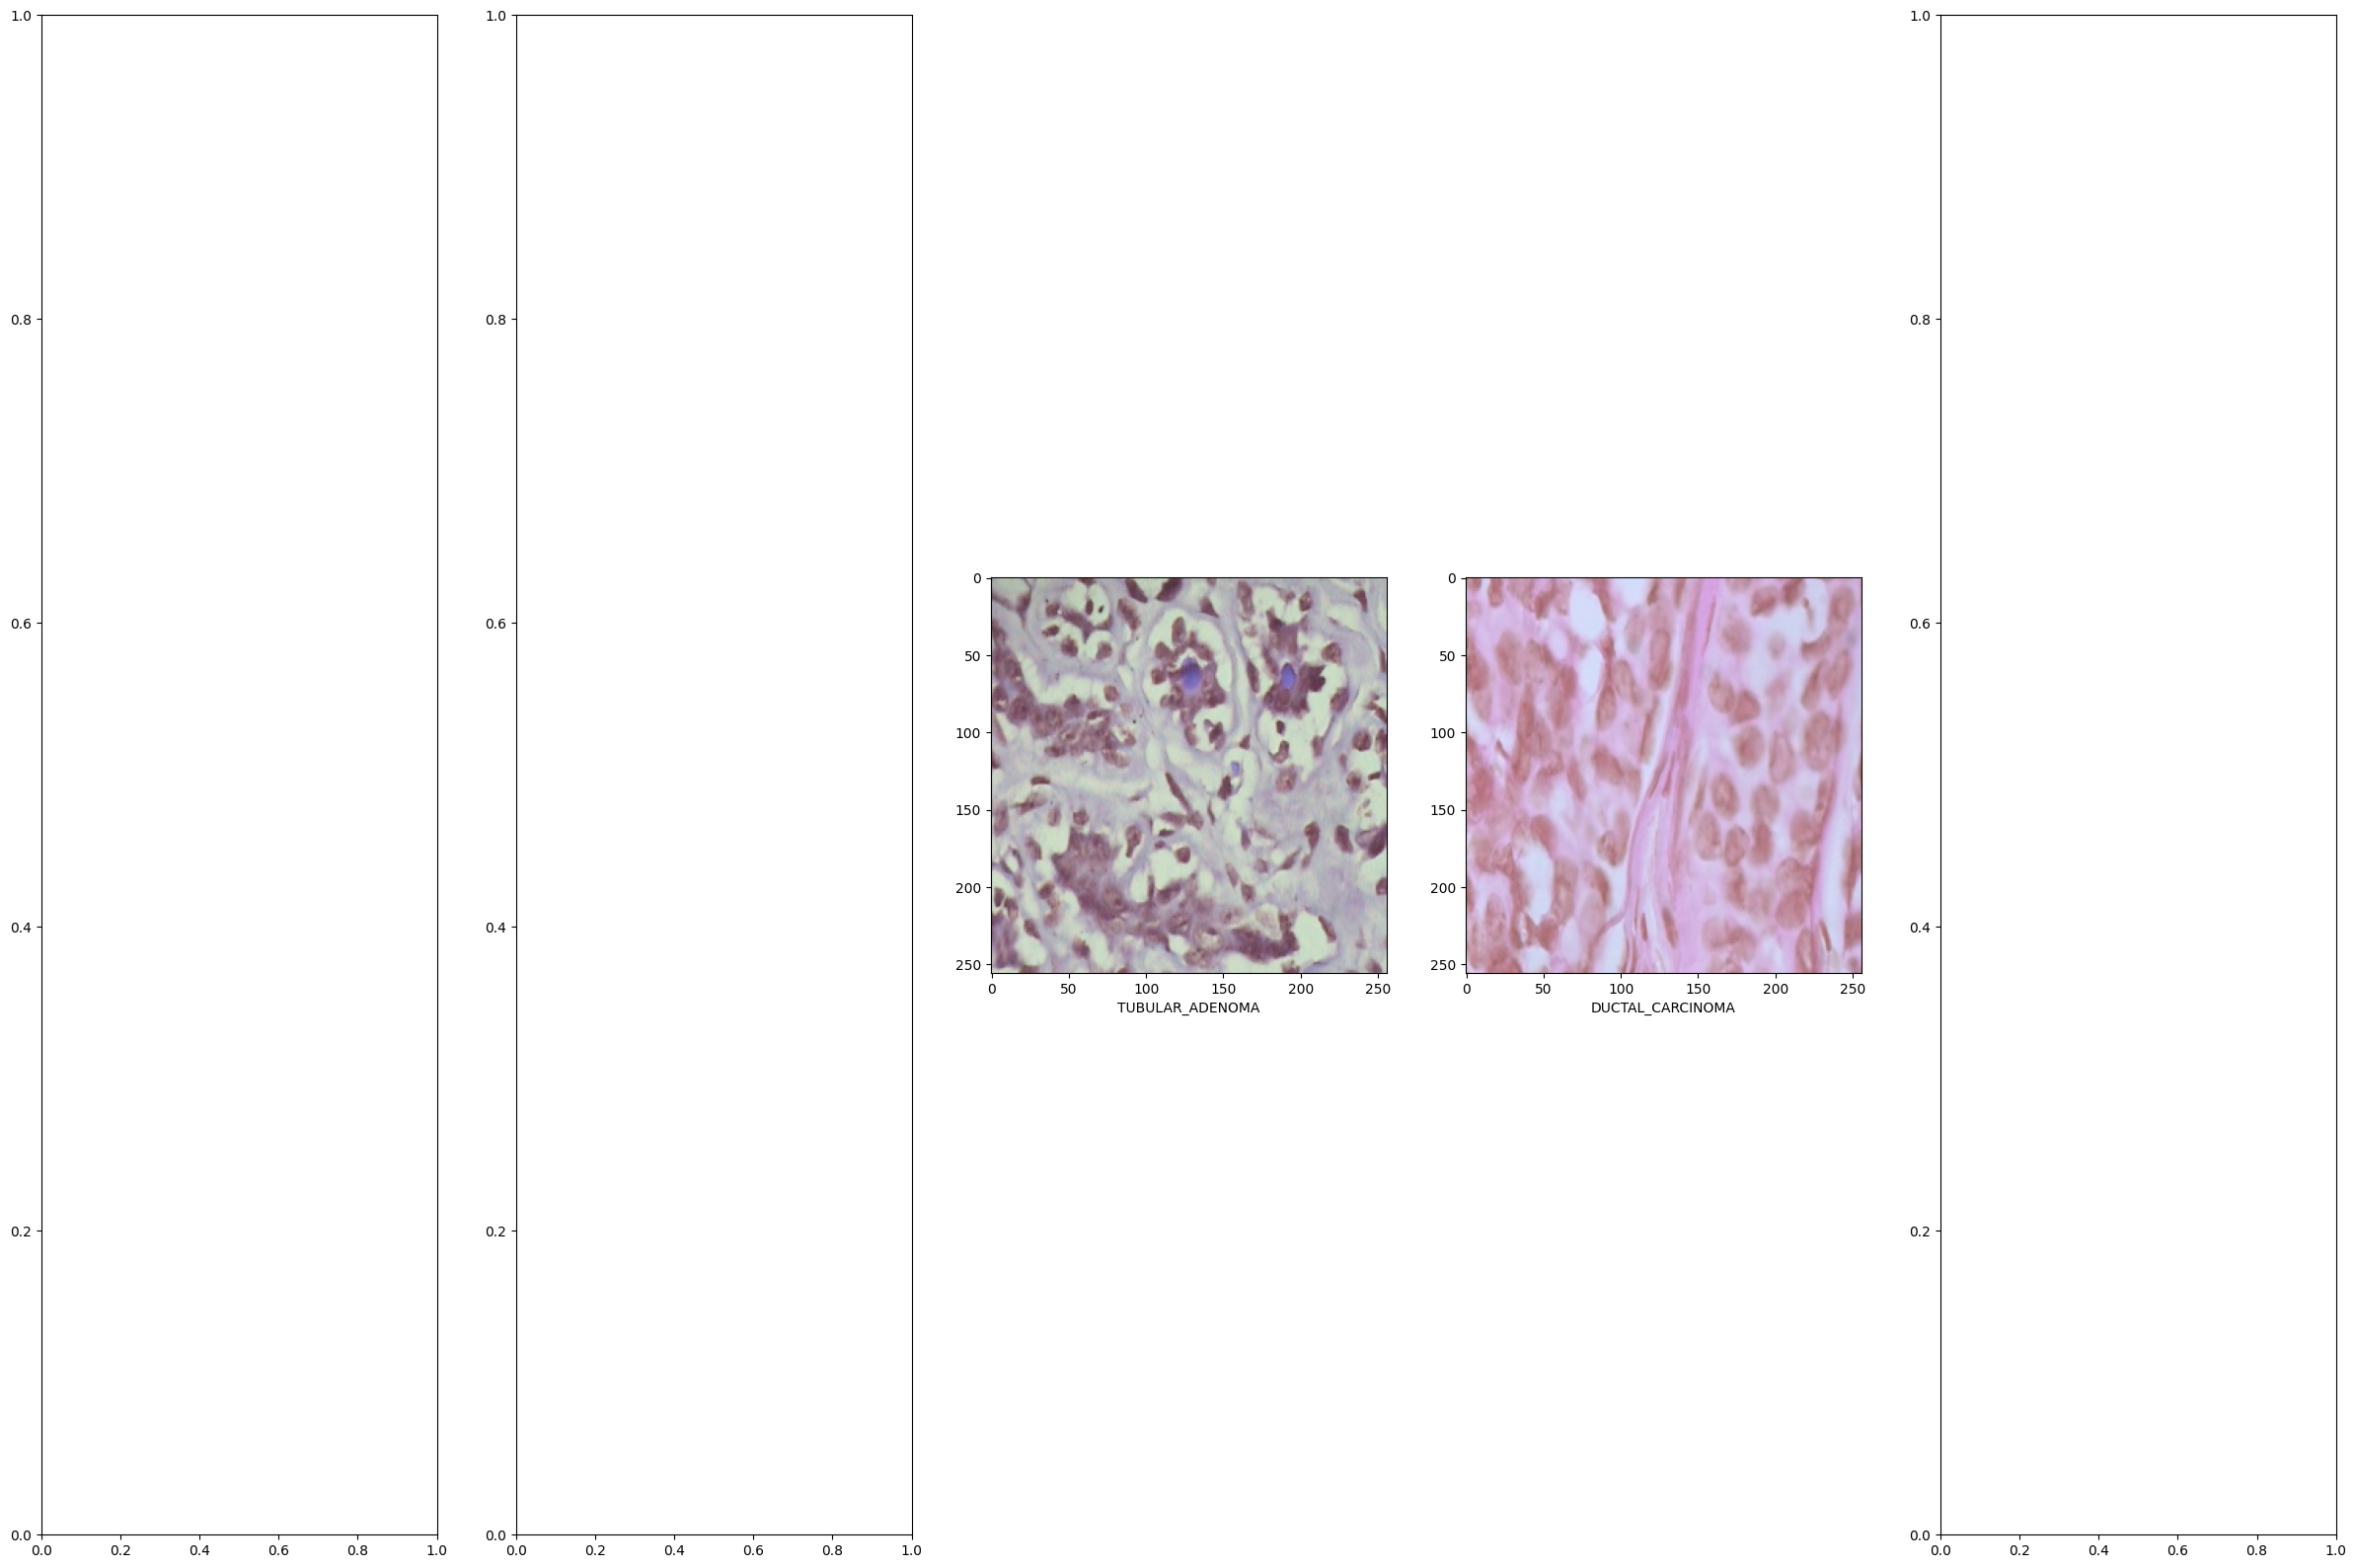

In [53]:
queryFeatures = features_retrieved_40[0]
results = perform_search(queryFeatures, training_indexed_40, max_results=5)
labels_ret = [training_indexed_40["labels"][r[1]] for r in results]

i = 0
f, axarr = plt.subplots(1, 5)
f.set_figheight(20)
f.set_figwidth(30)
for l in labels_ret:
  try:
    axarr[i].imshow(images_train[results[i][1]])
    axarr[i].set_xlabel(l.upper())
  except:
    print(i)
  i += 1
plt.show()

In [28]:
# test 400 model tflite
interpreter = tf.lite.Interpreter(model_path=str('tflite_model/subclass_encoder_400.tflite'))
interpreter.allocate_tensors()

input_index = interpreter.get_input_details()[0]["index"]
output_index = interpreter.get_output_details()[0]["index"]

interpreter.set_tensor(input_index, test_sample)
interpreter.invoke()
predictions = interpreter.get_tensor(output_index)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [29]:
query_indexes = list(range(0, test_x.shape[0]))
label_builder = list(np.unique(training_indexed_400["labels"]))
class_builder = {label_unique:[] for label_unique in label_builder}

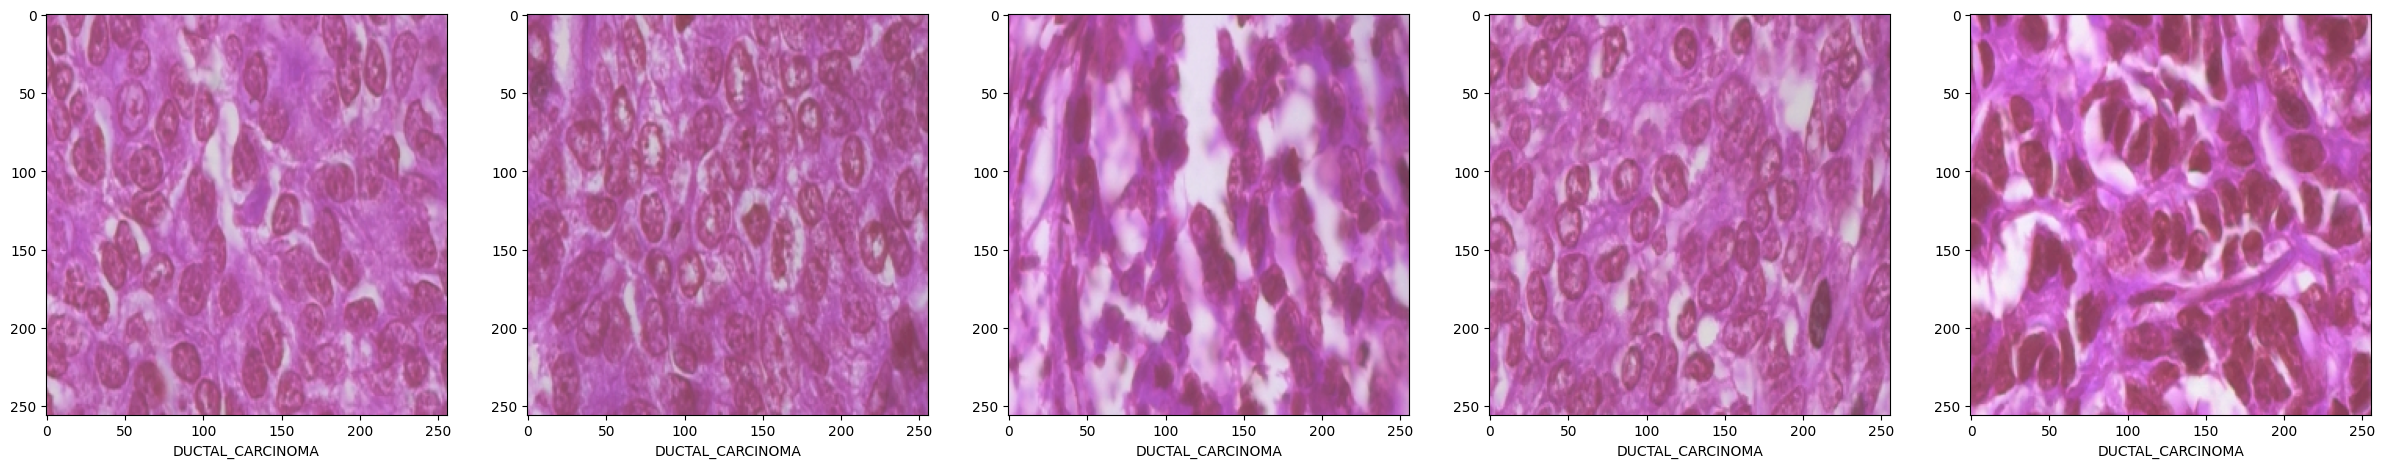

In [30]:
queryFeatures = predictions[0]
results = perform_search(queryFeatures, training_indexed_400, max_results=5)
labels_ret = [training_indexed_400["labels"][r[1]] for r in results]

i = 0
f, axarr = plt.subplots(1, 5)
f.set_figheight(20)
f.set_figwidth(30)
for l in labels_ret:
  axarr[i].imshow(images_train[results[i][1]])
  axarr[i].set_xlabel(l.upper())
  i += 1
plt.show()

In [31]:
encoder_400.save("tflite_model/subclass_h5_model.h5")